## Adding a Set of Particles to a Simulation

To add a collection of (optionally) self gravitating particles that (optionally) experience external forces to your simulation, use the {meth}`~tambora.simulation.Sim.add_particles` method.

The positions and velocities are expected to be (N, 3) arrays in cartesian coordinates and the masses an (N,) array. Positions are expected to be provided in units of kpc, the velocities in km/s, and masses in solar masses.

The following code segment adds 2 particles to the simulations as set1:

In [2]:
set1_pos = [[8., 0., 0.], [10, 0., 2.]] # kpc
set1_vel = [[0., 220., 0.], [0., 110., -20.]] # km/s 
set1_mass = [1., 10.] # Msun

from tambora.simulation import Sim

mysim = Sim()
mysim.add_particles('set1', set1_pos, set1_vel, set1_mass)

Notice that you must name the collection of particles when you add them to the simulation. The name you provide is used to access individual components of simulations with multiple components (discussed in [Adding Multiple Sets of Particles](#adding-multiple-sets-of-particles-to-a-simulation)). Particles can only be added before the simulation has been run.

## Adding Multiple Sets of Particles to a Simulation

You may want to include multiple sets of particles in your simulation that are handled differently. Adding multiple sets of particles works just like [adding an individual set](#adding-a-set-of-particles-to-a-simulation), as long as the provided name is different than that of the existing components.

In [9]:
from tambora.simulation import Sim
mysim = Sim() 

# --- Generate ICs for two sets of particles -------------- #
from tambora.tools import mkPlummer_galpy
pos1, vel1, mass1 = mkPlummer_galpy(1e9, b=3, n=1000, center_pos=[-5, -5, 0], center_vel=[20, 0, 0])
pos2, vel2, mass2 = mkPlummer_galpy(1e9, b=1, n=1000, center_pos=[5, 5, 0], center_vel=[-20, 0, 0])

# --- Add both sets of particles to the simulation --- #
mysim.add_particles('set1', pos1, vel1, mass1)
mysim.add_particles('set2', pos2, vel2, mass2)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

prog_host_orbs = Sim()
prog_host_orbs.add_particles('host', [np.mean(pos1, axis=0)], [np.mean(vel1, axis=0)], [np.sum(mass1)])
prog_host_orbs.add_particles('sat', [np.mean(pos2, axis=0)], [np.mean(vel2, axis=0)], [np.sum(mass2)])
prog_host_orbs.run(t_end=0.4, dt=0.001, dt_out=0.01, eps=0.01)



100%|██████████| 400/400 [00:00<00:00, 25861.63it/s]


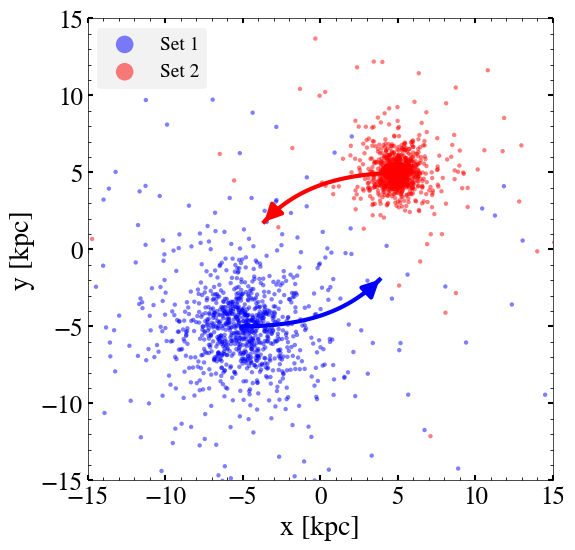

In [5]:
plt.figure(figsize=(6, 6))
def plot_orbit(orbit, color, lw=3):
    x, y = orbit.x(), orbit.y()
    plt.plot(x, y, c=color, alpha=1.0, lw=lw)
    plt.annotate(
        "", xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=25),
    )
plot_orbit(prog_host_orbs.host, "blue")
plot_orbit(prog_host_orbs.sat, "red")

plt.scatter(mysim.set1.x(0), mysim.set1.y(0), s=10, alpha=0.5, c='blue', label='Set 1')
plt.scatter(mysim.set2.x(0), mysim.set2.y(0), s=10, alpha=0.5, c='red', label='Set 2')
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.xlabel('x [kpc]', fontsize=20)
plt.ylabel('y [kpc]', fontsize=20)
plt.legend(fontsize=14, loc='upper left', markerscale=4)
plt.show()

**NOTE**: Need to add a method that lists the names of existing components. Also add check that the pos, vel, and masses the user is attempting to add does not overlap with an existing component.

## API

```{eval-rst}

.. automethod:: tambora.simulation.Sim.add_particles

```